<a href="https://colab.research.google.com/github/mannatdhull124/Insurance-Cost-Prediction/blob/main/Mylinearregressionproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📌 Problem Statement

The objective of this project is to predict medical insurance charges using Linear Regression.

The dataset contains demographic and health-related information such as age, BMI, smoking status, number of children, hospital expenditure, and annual salary.

Insurance companies need to estimate medical costs accurately to design appropriate policies and premiums.

The goal is to build a regression model that can predict the insurance charges based on the given features.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving insurance_data.csv to insurance_data (1).csv


In [ ]:
df = pd.read_csv('/content/insurance_data.csv')

In [ ]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


# EDA

Get basic info about the dataset. Check null values, duplicate value.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [ ]:
df.isnull().sum()  # We will get the null values with respect to the columns


,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [ ]:
df.isnull().sum().sum()

np.int64(52)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


In [ ]:
# 52 null values

In [ ]:
# Let's replace null values

# Numerical column: Mean
# Categorical column: Mode

In [ ]:
# Approach : We need to go through each and every column of our dataset
# Then we need to check the data type of every column that we will be going through
# If the datatype of column == numerical (int,float) we will replace it with mean
# If the datatype of column == categorical we will replace with mode

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [ ]:
df['smoker'].mode()[0]

'no'

In [ ]:
for x in df.columns:
  if df[x].dtype=='object':
    df[x].fillna(df[x].mode()[0],inplace=True)
  else:
    df[x].fillna(df[x].mean(),inplace=True)

/tmp/ipykernel_7578/3530114279.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[x].fillna(df[x].mean(),inplace=True)
/tmp/ipykernel_7578/3530114279.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

In [ ]:
df['region'].mode()

,region
0,southeast


In [ ]:
df['region'].mode()[0]

'southeast'

In [ ]:
pd.Series([10])

,0
0,10


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
Claim_Amount,0
past_consultations,0
num_of_steps,0
Hospital_expenditure,0
NUmber_of_past_hospitalizations,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1338 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1338 non-null   float64
 3   children                         1338 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1338 non-null   float64
 6   past_consultations               1338 non-null   float64
 7   num_of_steps                     1338 non-null   float64
 8   Hospital_expenditure             1338 non-null   float64
 9   NUmber_of_past_hospitalizations  1338 non-null   float64
 10  Anual_Salary                     1338 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

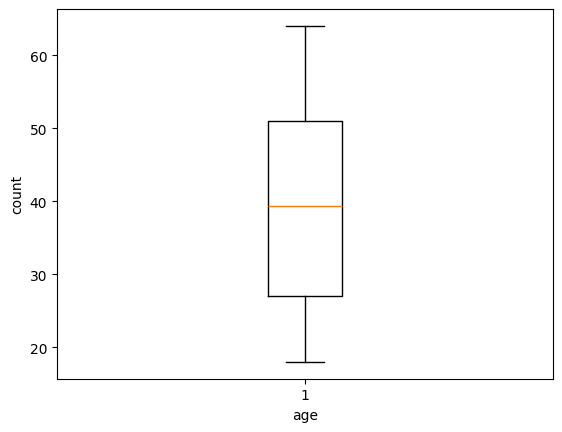

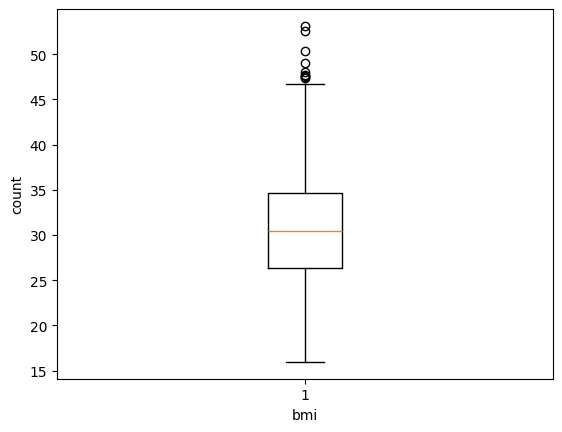

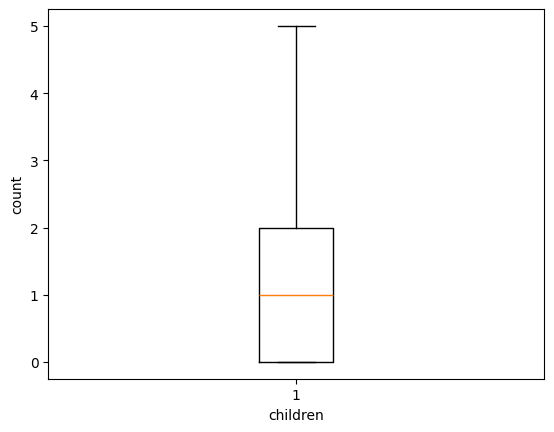

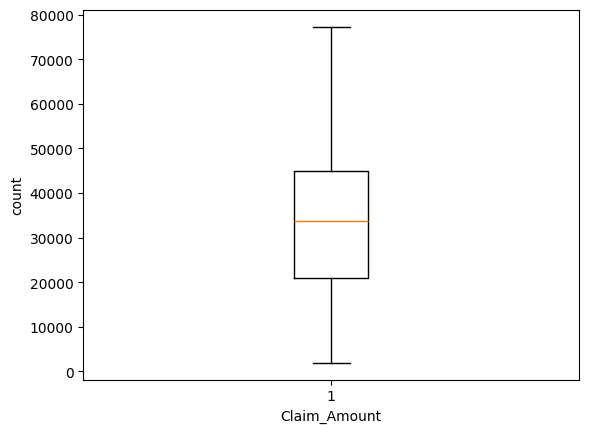

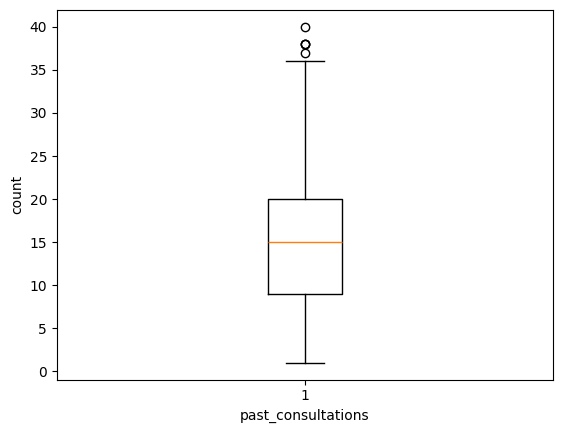

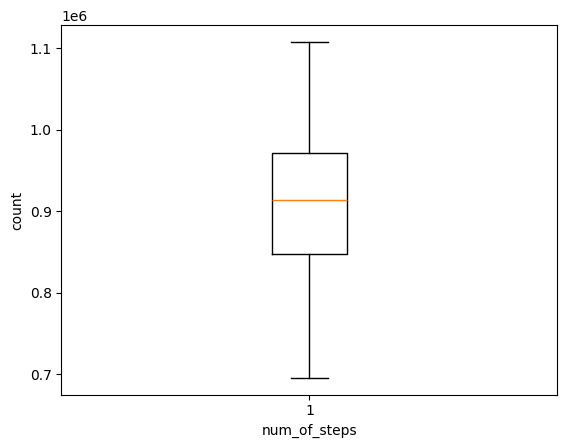

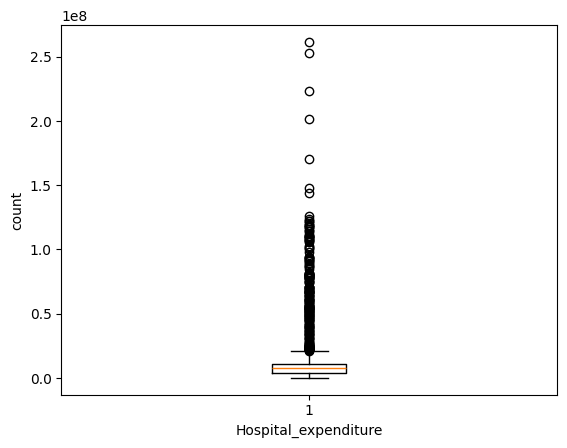

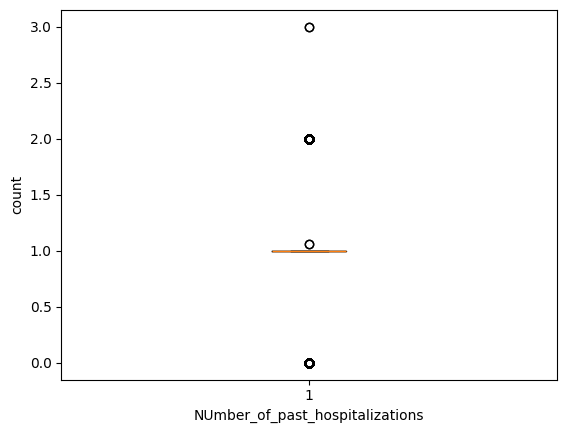

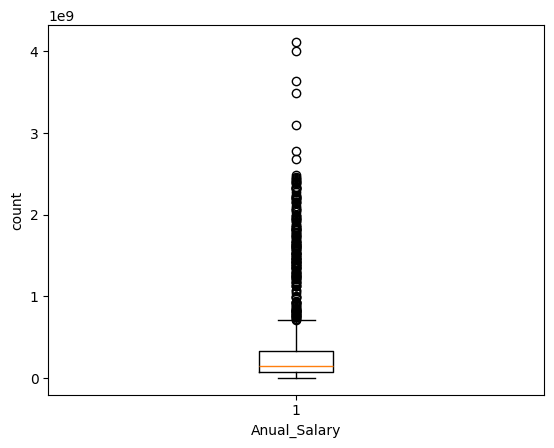

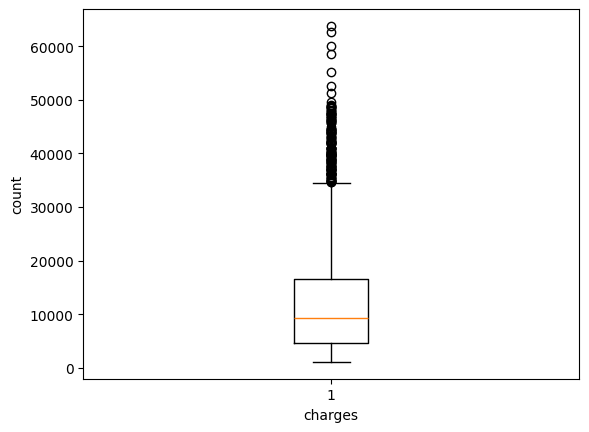

In [ ]:
for x in df.columns:
  if df[x].dtype!='object':
    plt.boxplot(df[x])
    plt.xlabel(x)
    plt.ylabel('count')
    plt.show()

In [ ]:
for x in df.columns:    # this wil loop through each column
  if df[x].dtype=='object' or x=='charges':
    continue    # it will skip the object column and charges as well because it is the target

  Q1 = df[x].quantile(0.25)
  Q3 = df[x].quantile(0.75)
  IQR = Q3-Q1
  lower_fence = Q1-1.5*IQR
  upper_fence = Q3+1.5*IQR
  df = df[(df[x]>=lower_fence) & (df[x]<=upper_fence)]  # if value is below lower fence of above upper fence is considered as outlier

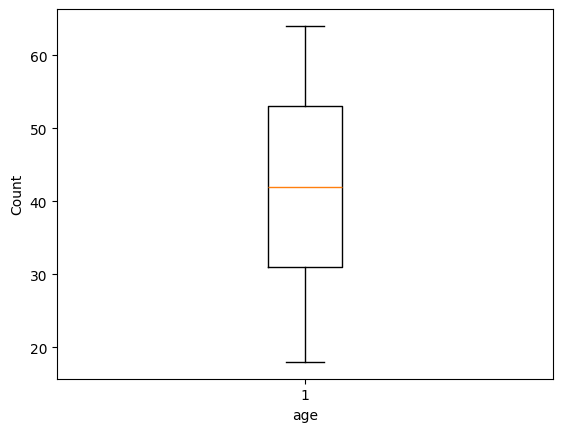

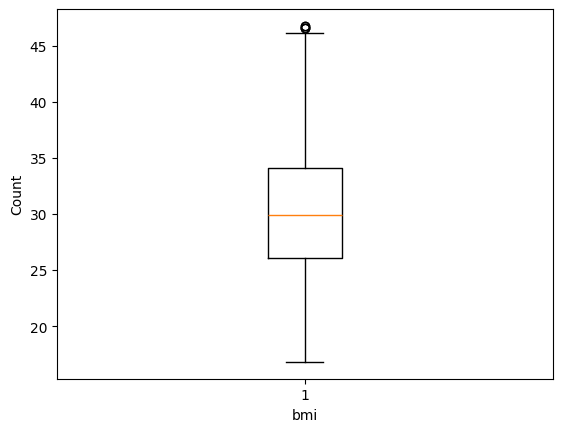

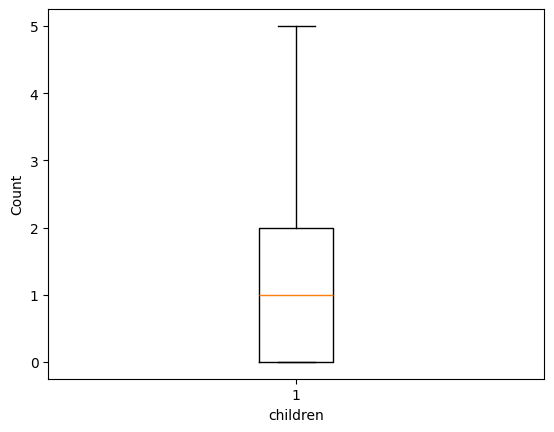

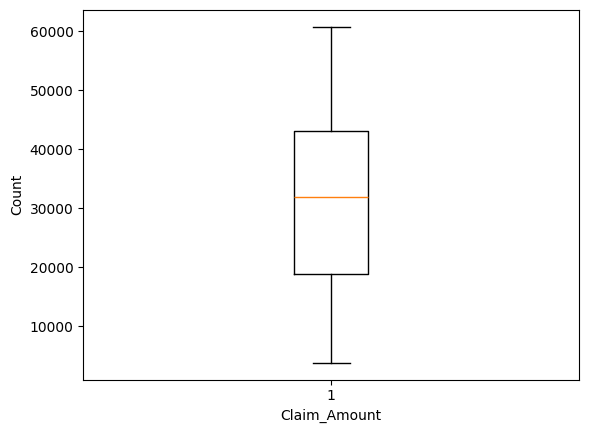

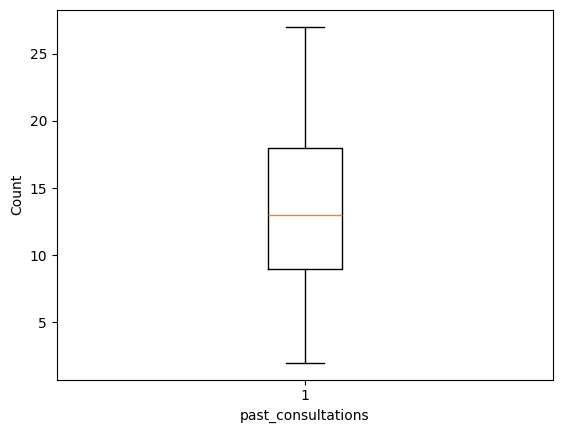

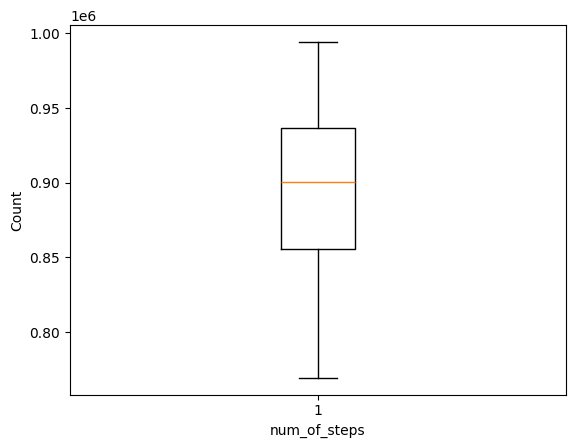

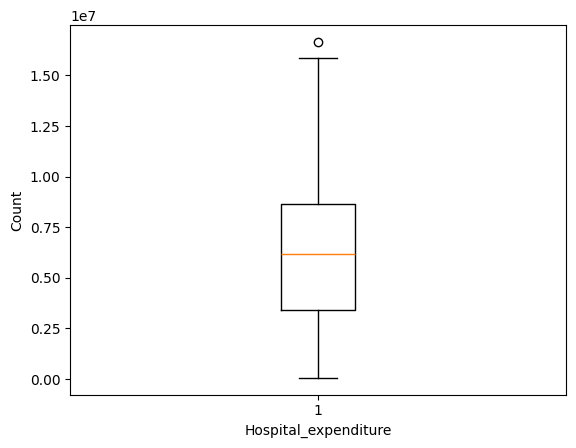

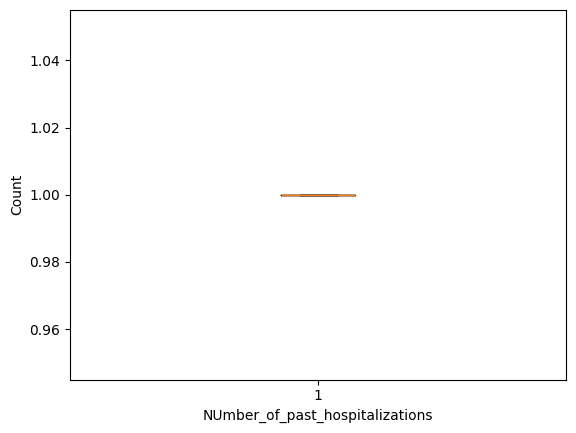

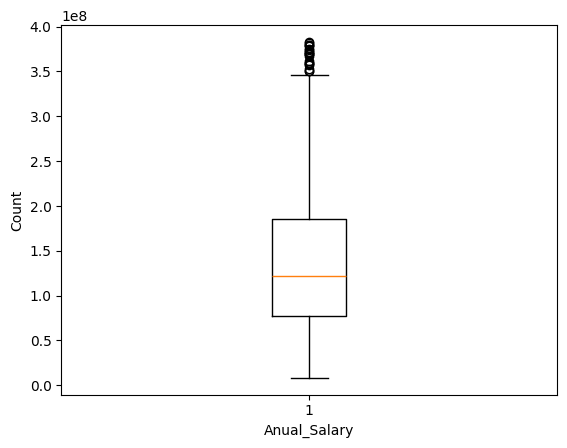

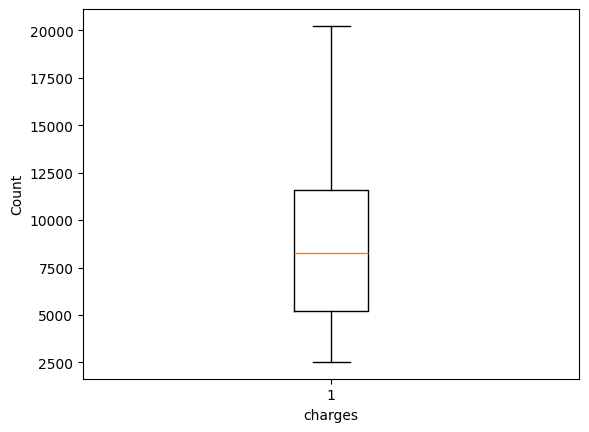

In [ ]:
for x in df.columns:
  if df[x].dtype!='object':
    plt.boxplot(df[x])
    plt.xlabel(x)
    plt.ylabel('Count')
    plt.show()

In [ ]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
151,25.0,male,27.550,0.0,no,39148.95495,10.0,780652.0,8.614147e+06,1.0,5.452601e+07,northwest,2523.16950
152,22.0,female,20.235,0.0,no,41547.52536,13.0,802627.0,2.491594e+05,1.0,1.671847e+07,northwest,2527.81865
153,25.0,male,35.625,0.0,no,39660.60193,12.0,770773.0,3.043323e+06,1.0,4.852694e+07,northwest,2534.39375
154,20.0,male,31.130,2.0,no,16032.87148,7.0,769255.0,1.599069e+06,1.0,2.441262e+07,southeast,2566.47070
155,21.0,female,17.400,1.0,no,31090.98977,21.0,778769.0,3.015365e+06,1.0,5.853579e+07,southwest,2585.26900
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046,29.0,female,27.940,1.0,yes,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,southeast,19107.77960
1048,31.0,male,25.900,3.0,yes,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08,southwest,19199.94400
1050,31.0,male,29.810,0.0,yes,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08,southeast,19350.36890
1062,43.0,female,20.045,2.0,yes,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08,northeast,19798.05455


In [ ]:
# Feature selection

# VIF : Variance inflation factor
# VIF helps us to detect the multicolinearity among the columns.
# If your vif>=6 it means that column is not important for us, as it having high multicolinearity. We will remove those


In [ ]:
col_list = []
for x in df.columns:
  if df[x].dtype!='object' and x!='charges':
    col_list.append(x)

In [ ]:
col_list    # all independent numerical columns

['age',
 'bmi',
 'children',
 'Claim_Amount',
 'past_consultations',
 'num_of_steps',
 'Hospital_expenditure',
 'NUmber_of_past_hospitalizations',
 'Anual_Salary']

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
dummy = df[col_list]
dummy

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary
151,25.0,27.550,0.0,39148.95495,10.0,780652.0,8.614147e+06,1.0,5.452601e+07
152,22.0,20.235,0.0,41547.52536,13.0,802627.0,2.491594e+05,1.0,1.671847e+07
153,25.0,35.625,0.0,39660.60193,12.0,770773.0,3.043323e+06,1.0,4.852694e+07
154,20.0,31.130,2.0,16032.87148,7.0,769255.0,1.599069e+06,1.0,2.441262e+07
155,21.0,17.400,1.0,31090.98977,21.0,778769.0,3.015365e+06,1.0,5.853579e+07
...,...,...,...,...,...,...,...,...,...
1046,29.0,27.940,1.0,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08
1048,31.0,25.900,3.0,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08
1050,31.0,29.810,0.0,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08
1062,43.0,20.045,2.0,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08


In [ ]:
pd.DataFrame(dummy.values)

,0,1,2,3,4,5,6,7,8
0,25.0,27.550,0.0,39148.95495,10.0,780652.0,8.614147e+06,1.0,5.452601e+07
1,22.0,20.235,0.0,41547.52536,13.0,802627.0,2.491594e+05,1.0,1.671847e+07
2,25.0,35.625,0.0,39660.60193,12.0,770773.0,3.043323e+06,1.0,4.852694e+07
3,20.0,31.130,2.0,16032.87148,7.0,769255.0,1.599069e+06,1.0,2.441262e+07
4,21.0,17.400,1.0,31090.98977,21.0,778769.0,3.015365e+06,1.0,5.853579e+07
...,...,...,...,...,...,...,...,...,...
876,29.0,27.940,1.0,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08
877,31.0,25.900,3.0,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08
878,31.0,29.810,0.0,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08
879,43.0,20.045,2.0,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08


In [ ]:
vif_data = pd.DataFrame()
vif_data['Feature'] = dummy.columns   # In this feature column we are having all the independent numerical columns of our actual dataframe
vif_data
vif_list = []

for i in range (len(dummy.columns)):
  vif = variance_inflation_factor(dummy.values,i)  # i will be the column index
  vif_list.append(vif)
vif_data['VIF'] = vif_list

In [ ]:
vif_data

,Feature,VIF
0,age,2.196194
1,bmi,1.052717
2,children,1.076523
3,Claim_Amount,1.035033
4,past_consultations,1.073989
5,num_of_steps,5.882074
6,Hospital_expenditure,1.173208
7,NUmber_of_past_hospitalizations,1393.169724
8,Anual_Salary,3.983678


In [ ]:
df = df.drop(['NUmber_of_past_hospitalizations'],axis=1)

In [ ]:
col_list = []
for x in df.columns:
  if df[x].dtype!='object' and x!='charges':
    col_list.append(x)

dummy = df[col_list]
vif_data= pd.DataFrame()
vif_data['Feature']= col_list
vif_data
vif_list = []
for i in range(len(dummy.columns)):
  vif = variance_inflation_factor(dummy.values,i)
  vif_list.append(vif)
vif_data['VIF']= vif_list

In [ ]:
vif_data

,Feature,VIF
0,age,16.357708
1,bmi,26.868143
2,children,2.069345
3,Claim_Amount,5.864753
4,past_consultations,6.463488
5,num_of_steps,58.376344
6,Hospital_expenditure,5.423018
7,Anual_Salary,6.000703


In [ ]:
df = df.drop(columns=['num_of_steps'])

In [ ]:
col_list = []
for x in df.columns:
  if df[x].dtype!='object' and x!='charges':
    col_list.append(x)

dummy = df[col_list]
vif_data= pd.DataFrame()
vif_data['Feature']= col_list
vif_data
vif_list = []
for i in range(len(dummy.columns)):
  vif = variance_inflation_factor(dummy.values,i)
  vif_list.append(vif)
vif_data['VIF']= vif_list

In [ ]:
vif_data

,Feature,VIF
0,age,13.550906
1,bmi,14.522848
2,children,1.954239
3,Claim_Amount,5.319321
4,past_consultations,5.957746
5,Hospital_expenditure,5.142291
6,Anual_Salary,5.783595


In [ ]:
df = df.drop(columns=['bmi'])

In [ ]:
col_list = []
for x in df.columns:
  if df[x].dtype!='object' and x!='charges':
    col_list.append(x)

dummy = df[col_list]
vif_data= pd.DataFrame()
vif_data['Feature']= col_list
vif_data
vif_list = []
for i in range(len(dummy.columns)):
  vif = variance_inflation_factor(dummy.values,i)
  vif_list.append(vif)
vif_data['VIF']= vif_list

In [ ]:
vif_data

,Feature,VIF
0,age,8.803866
1,children,1.835999
2,Claim_Amount,4.912972
3,past_consultations,5.613220
4,Hospital_expenditure,4.840950
5,Anual_Salary,5.636699


In [ ]:
df = df.drop(columns=['age'])

In [ ]:
col_list = []
for x in df.columns:
  if df[x].dtype!='object' and x!='charges':
    col_list.append(x)

dummy = df[col_list]
vif_data= pd.DataFrame()
vif_data['Feature']= col_list
vif_data
vif_list = []
for i in range(len(dummy.columns)):
  vif = variance_inflation_factor(dummy.values,i)
  vif_list.append(vif)
vif_data['VIF']= vif_list

In [ ]:
vif_data

,Feature,VIF
0,children,1.827298
1,Claim_Amount,4.290828
2,past_consultations,4.942338
3,Hospital_expenditure,4.624025
4,Anual_Salary,4.922027


In [ ]:
df

,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,Anual_Salary,region,charges
151,male,0.0,no,39148.95495,10.0,8.614147e+06,5.452601e+07,northwest,2523.16950
152,female,0.0,no,41547.52536,13.0,2.491594e+05,1.671847e+07,northwest,2527.81865
153,male,0.0,no,39660.60193,12.0,3.043323e+06,4.852694e+07,northwest,2534.39375
154,male,2.0,no,16032.87148,7.0,1.599069e+06,2.441262e+07,southeast,2566.47070
155,female,1.0,no,31090.98977,21.0,3.015365e+06,5.853579e+07,southwest,2585.26900
...,...,...,...,...,...,...,...,...,...
1046,female,1.0,yes,51168.25474,23.0,1.665982e+07,3.712188e+08,southeast,19107.77960
1048,male,3.0,yes,46619.40230,27.0,1.361938e+07,3.812895e+08,southwest,19199.94400
1050,male,0.0,yes,24382.58056,21.0,1.028991e+07,3.745310e+08,southeast,19350.36890
1062,female,2.0,yes,21596.43846,10.0,1.083030e+07,3.696849e+08,northeast,19798.05455


# ⚙️ Solution Approach

To solve the insurance cost prediction problem, the following steps were performed:

1. Data Preprocessing:
   - Handled missing values in numerical and categorical features
   - Converted categorical variables (sex, smoker, region) into numerical form using encoding techniques
   - Prepared dataset for modeling

2. Exploratory Data Analysis (EDA):
   - Used histograms and boxplots to understand data distribution
   - Identified outliers in features like BMI and charges
   - Analyzed relationships between features and charges

3. Feature Scaling:
   - Applied standardization to normalize numerical features

4. Model Building:
   - Implemented Linear Regression model
   - Linear Regression predicts continuous values based on linear relationships between variables

5. Model Evaluation:
   - Evaluated using metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score
   - Compared predicted values with actual values

6. Interpretation:
   - Analyzed model coefficients to understand feature impact
   - Identified key factors influencing insurance charges (e.g., smoker, BMI, hospital expenditure)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
for x in df.columns:
  if df[x].dtype=='object':
    df[x]=le.fit_transform(df[x])

In [ ]:
df

,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,Anual_Salary,region,charges
151,1,0.0,0,39148.95495,10.0,8.614147e+06,5.452601e+07,1,2523.16950
152,0,0.0,0,41547.52536,13.0,2.491594e+05,1.671847e+07,1,2527.81865
153,1,0.0,0,39660.60193,12.0,3.043323e+06,4.852694e+07,1,2534.39375
154,1,2.0,0,16032.87148,7.0,1.599069e+06,2.441262e+07,2,2566.47070
155,0,1.0,0,31090.98977,21.0,3.015365e+06,5.853579e+07,3,2585.26900
...,...,...,...,...,...,...,...,...,...
1046,0,1.0,1,51168.25474,23.0,1.665982e+07,3.712188e+08,2,19107.77960
1048,1,3.0,1,46619.40230,27.0,1.361938e+07,3.812895e+08,3,19199.94400
1050,1,0.0,1,24382.58056,21.0,1.028991e+07,3.745310e+08,2,19350.36890
1062,0,2.0,1,21596.43846,10.0,1.083030e+07,3.696849e+08,0,19798.05455


In [ ]:
X = df.iloc[:,:8]  #independent variable
y = df.iloc[:,-1]  #dependent variable

In [ ]:
X

,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,Anual_Salary,region
151,1,0.0,0,39148.95495,10.0,8.614147e+06,5.452601e+07,1
152,0,0.0,0,41547.52536,13.0,2.491594e+05,1.671847e+07,1
153,1,0.0,0,39660.60193,12.0,3.043323e+06,4.852694e+07,1
154,1,2.0,0,16032.87148,7.0,1.599069e+06,2.441262e+07,2
155,0,1.0,0,31090.98977,21.0,3.015365e+06,5.853579e+07,3
...,...,...,...,...,...,...,...,...
1046,0,1.0,1,51168.25474,23.0,1.665982e+07,3.712188e+08,2
1048,1,3.0,1,46619.40230,27.0,1.361938e+07,3.812895e+08,3
1050,1,0.0,1,24382.58056,21.0,1.028991e+07,3.745310e+08,2
1062,0,2.0,1,21596.43846,10.0,1.083030e+07,3.696849e+08,0


In [ ]:
y

,charges
151,2523.16950
152,2527.81865
153,2534.39375
154,2566.47070
155,2585.26900
...,...
1046,19107.77960
1048,19199.94400
1050,19350.36890
1062,19798.05455


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X,y,train_size=0.8,random_state=7)

In [ ]:
x_train

,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,Anual_Salary,region
217,0,0.0,0,6130.345486,15.0,2.046063e+06,6.508980e+07,3
777,0,0.0,0,48856.609420,9.0,7.834785e+06,1.252456e+08,1
160,1,1.0,0,27356.102420,4.0,2.158890e+06,9.739940e+07,1
1007,1,0.0,1,25808.795930,21.0,7.445284e+06,2.944865e+08,2
516,1,2.0,0,51466.023220,16.0,3.901163e+05,6.759640e+07,2
...,...,...,...,...,...,...,...,...
733,0,3.0,0,33361.327180,14.0,6.087441e+06,1.809741e+08,2
654,1,0.0,0,42322.350080,16.0,3.888710e+06,1.012005e+08,1
690,0,3.0,0,21457.303480,10.0,5.296198e+06,1.224163e+08,0
347,1,4.0,0,43279.048460,9.0,2.977256e+06,1.100850e+08,1


In [ ]:
y_train.shape

(704,)

In [ ]:
x_test.shape

(177, 8)

In [ ]:
y_test.shape

(177,)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred

array([ 5719.63163937,  8999.79622555,  8905.44570268,  7565.70106779,
       18667.38420813, 15104.05862658,  8187.55350691,  5464.34528026,
        7984.65470797,  4828.94707611, 11741.68956832,  5965.17970245,
        4787.43970567, 17617.1950153 ,  7228.25099913,  9913.60505079,
       12340.75901549, 15501.88787997,  7020.90384824,  5482.60264909,
       12442.39953136,  5444.93765054, 15682.19231586,  5788.96144747,
       10329.36949435,  6896.66143708,  8923.90386503,  4474.14912656,
       13184.00952941,  6138.84727996,  3348.2942117 ,  8546.06033809,
       16644.6327483 ,  7008.97431675,  2864.53466557,  7819.25788974,
       11794.35557882,  9582.77896032,  8257.85854267, 12064.1416739 ,
       18613.69356072,  5060.59594842, 12500.64872383,  6743.21232873,
        6015.28887067,  5519.79380567, 16755.56311875,  9269.00533432,
        9259.31380883,  4878.0358731 ,  8653.17764501, 15476.82666225,
        4573.52240732,  7886.35392991, 13545.49553767,  8562.97854189,
      

In [ ]:
error = pd.DataFrame(columns=['Actual values','Predicted values'])

In [ ]:
error

,Actual values,Predicted values


In [ ]:
error['Actual values']= y_test
error['Predicted values']=y_pred
error

,Actual values,Predicted values
197,3077.09550,5719.631639
662,9283.56200,8999.796226
619,8601.32930,8905.445703
298,4399.73100,7565.701068
1026,18157.87600,18667.384208
...,...,...
598,8347.16430,7838.201186
232,3537.70300,5710.002312
726,10231.49990,7126.094785
757,10796.35025,11159.880189


In [ ]:
error['Error rate'] = error['Actual values'] - error['Predicted values']


In [ ]:
error

,Actual values,Predicted values,Error rate
197,3077.09550,5719.631639,-2642.536139
662,9283.56200,8999.796226,283.765774
619,8601.32930,8905.445703,-304.116403
298,4399.73100,7565.701068,-3165.970068
1026,18157.87600,18667.384208,-509.508208
...,...,...,...
598,8347.16430,7838.201186,508.963114
232,3537.70300,5710.002312,-2172.299312
726,10231.49990,7126.094785,3105.405115
757,10796.35025,11159.880189,-363.529939


In [ ]:

from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
mse = mean_squared_error(y_test,y_pred)

In [ ]:
print(mse)

2674836.1369436677


In [ ]:
rmse = np.sqrt(mse)

In [ ]:
rmse

np.float64(1635.4926282144067)

In [ ]:
r2_accuracy = r2_score(y_test,y_pred)
r2_accuracy*100

85.96118266582677

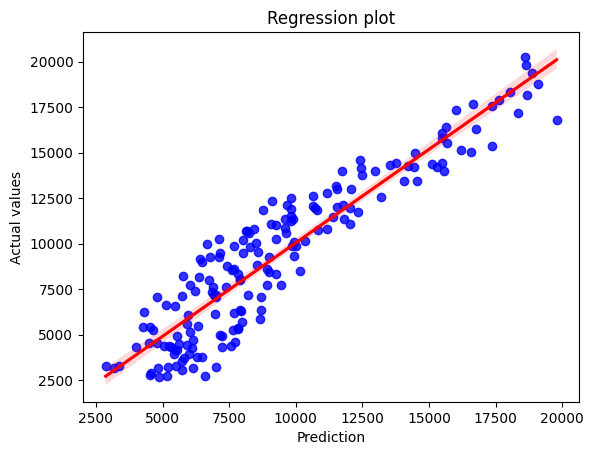

In [ ]:
# regression plot

sns.regplot(x=y_pred,y=y_test,line_kws={'color':'red'},color='blue')
plt.xlabel('Prediction')
plt.ylabel('Actual values')
plt.title('Regression plot')
plt.show()

# 📈 Results and Conclusion

The Linear Regression model successfully predicted insurance charges based on customer and medical data.

The model showed that features like smoking status, BMI, and hospital expenditure significantly impact insurance costs.

Smokers tend to have higher insurance charges compared to non-smokers, indicating higher health risks.

The model can help insurance companies estimate premiums and assist customers in understanding cost factors.

Thus, Linear Regression proves to be an effective and interpretable model for predicting continuous outcomes like insurance charges.